In [1]:
# Day 28 - Optimized ML Pipeline

import numpy as np
import pandas as pd

np.random.seed(42)
n = 100

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, n),
    "Income": np.random.randint(20000, 100000, n),
    "Purchase_Amount": np.random.randint(500, 5000, n),
    "Savings": np.random.randint(5000, 50000, n),
    "Credit_Score": np.random.randint(300, 850, n)
})

df["Purchased"] = (
    (df["Purchase_Amount"] > 2000) |
    (df["Age"] < 25)
).astype(int)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (100, 6)


,Age,Income,Purchase_Amount,Savings,Credit_Score,Purchased
0,56,28392,646,16093,393,0
1,46,50535,3719,23070,752,1
2,32,98603,3411,40777,503,1
3,25,72256,2234,21538,517,1
4,38,55222,2343,15729,773,1


In [2]:
df["Income_per_Age"] = df["Income"] / df["Age"]

X = df.drop("Purchased", axis=1)
y = df["Purchased"]

print("Features:", X.columns.tolist())
print("Feature Shape:", X.shape)

Features: ['Age', 'Income', 'Purchase_Amount', 'Savings', 'Credit_Score', 'Income_per_Age']
Feature Shape: (100, 6)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (80, 6)
Testing Shape: (20, 6)


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

numeric_features = X.columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [5]:
from sklearn.ensemble import RandomForestClassifier

ml_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

print("Complete ML pipeline created successfully.")

Complete ML pipeline created successfully.


In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [3, 5, 10, None]
}

grid_search = GridSearchCV(
    estimator=ml_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'model__max_depth': 3, 'model__n_estimators': 100}
Best CV Accuracy: 0.9625


In [7]:
best_pipeline = grid_search.best_estimator_

test_accuracy = best_pipeline.score(X_test, y_test)

print("Optimized Pipeline Test Accuracy:", test_accuracy)

Optimized Pipeline Test Accuracy: 1.0


In [8]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Random Forest (Day 25)",
        "Tuned Random Forest (Day 26)",
        "Optimized ML Pipeline (Day 28)"
    ],
    "CV_Accuracy": [
        0.98,
        0.98,
        grid_search.best_score_
    ]
})

print(comparison)

                            Model  CV_Accuracy
0          Random Forest (Day 25)       0.9800
1    Tuned Random Forest (Day 26)       0.9800
2  Optimized ML Pipeline (Day 28)       0.9625


In [9]:
comparison.to_csv("day28_final_performance_report.csv", index=False)

print("Final performance report saved successfully.")

Final performance report saved successfully.


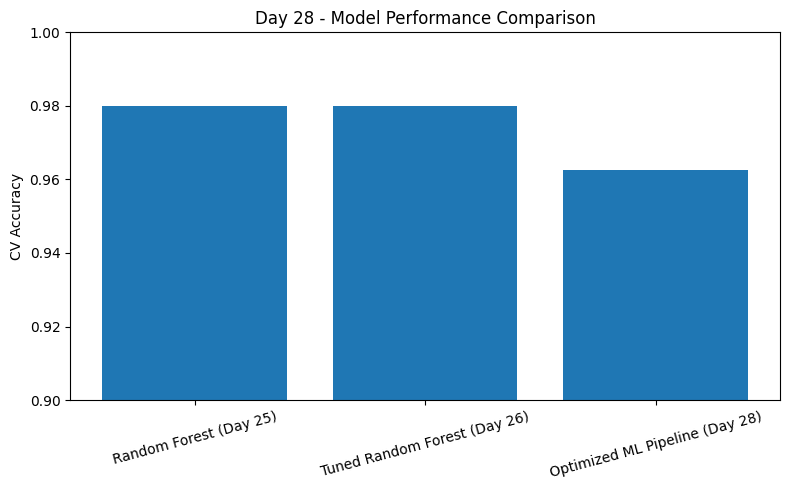

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(comparison["Model"], comparison["CV_Accuracy"])

plt.ylabel("CV Accuracy")
plt.title("Day 28 - Model Performance Comparison")
plt.xticks(rotation=15)
plt.ylim(0.9, 1.0)

plt.tight_layout()
plt.show()

In [11]:
print("===== DAY 28 FINAL RESULTS =====")
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)
print("Test Accuracy:", test_accuracy)
print("Report File: day28_final_performance_report.csv")
print("Reflection File: day28_week4_reflection.md")
print("README File: README_day28.md")

===== DAY 28 FINAL RESULTS =====
Best Parameters: {'model__max_depth': 3, 'model__n_estimators': 100}
Best CV Accuracy: 0.9625
Test Accuracy: 1.0
Report File: day28_final_performance_report.csv
Reflection File: day28_week4_reflection.md
README File: README_day28.md
